## **GSA for c-LCA** ##

This is a Juputer notebook to run sentitivity, uncertainty, and global sensitivity analysis (GSA) in LCA using parameters. 

**Author:** Christhel Andrade <br>
**Date:** 15th January 2026 <br>

This notebooks introduces first the notion behind parameters and then provides dedicated sections for running OAT, MonteCarlo, and GSA.

**Acknowledgements:**
This notebook builds on a previous version created by Rebecca Belfiore in 2025 for the ALIGNED project and later updated by Christhel Andrade for the STRONGER project.<br>

In [9]:
# Import bw2.5 packages
import bw2calc as bc
import bw2data as bd
import bw2io as bi
import bw2analyzer as bwa
import bw_processing as bwp

from bw2data.parameters import parameters, ActivityParameter, DatabaseParameter
from bw2data.backends.schema import ExchangeDataset
from lci_to_bw2 import *
from Importer_parameters import *
from Harmonizer import *

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

(*) Back codes in python required to run the parametric functions. Please be sure to contain these files in the folder where you contain this project
Make sure that all the required packages are installed in the environement.



## Import

In [10]:
bd.projects

Brightway2 projects manager with 40 objects, including:
	Agroforestry
	Agroforestry_bw25
	Agroforestry_bw25_2
	Agroforestry_bw25_3
	BIOCHAR_M2
	Biochar-C-seq
	Buildings Insulation
	HPO_MC
	HPO_SA
	HTL_SA
Use `sorted(projects)` to get full list, `projects.report()` to get
	a report on all projects.

Let's work in the previous project created

In [ ]:
bd.projects.set_current('new_project') # insert the name of your project 
bd.databases

Now we're going to work with a new project. <br>

### **Notice** ### 
The principle and basics behind the code are avalable in the repository of the [ALIGNED](https://zenodo.org/records/10842720) project.

This database contains parameters and formulas. Parameters may work at activity level (it can only be applied to the activity for which it was created) or at database level (it applies to all the activities in the whole database). <br>

This project is built using multiple databases building one over each other. It is important that all databased are loaded in the correct order of aparition.

In [ ]:
#import marginal energy supplier databases
ei = bi.ExcelImporter('path/file.xlsx') # to import the energy database in the project

ei.apply_strategies()
ei.match_database('ecoinvent-3.11-biosphere') # to match the project to biosphere
ei.match_database('ecoinvent-3.11-consequential') # to match the project to ecoinvent

ei.statistics() 

# to activate parameters
ei.write_project_parameters() 
ei.write_database(activate_parameters=True)

Extracted 1 worksheets in 0.06 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.38 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `Energy` importer:
17 graph nodes:
	process: 17
116 graph edges:
	

100%|██████████| 17/17 [00:00<00:00, 1175.42it/s]


10:38:31+0100 [info     ] Vacuuming database            
Created database: Energy


In [ ]:
#import marginal supplier databases
ei = bi.ExcelImporter('.path/file.xlsx') # to import the marginals database in the project

ei.apply_strategies()
ei.match_database('ecoinvent-3.11-biosphere') # to match the project to biosphere
ei.match_database('ecoinvent-3.11-consequential') # to match the project to ecoinvent
ei.match_database('Energy') # to match the marginal energy database

ei.statistics() 

# to activate parameters
ei.write_project_parameters() 
ei.write_database(activate_parameters=True)

Extracted 1 worksheets in 0.15 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.28 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `Marginals` importer:
7

100%|██████████| 7/7 [00:00<00:00, 111.43it/s]


10:39:08+0100 [info     ] Vacuuming database            
Created database: Marginals


In [ ]:
#Load Foreground database
ei = bi.ExcelImporter('.path/file.xlsx') # to import the foreground database in the project

ei.apply_strategies()
ei.match_database('ecoinvent-3.11-biosphere') # to match the project to biosphere
ei.match_database('ecoinvent-3.11-consequential') # to match the project to ecoinvent
ei.match_database('Energy') # to match the marginal energy database
ei.match_database('Marginals') # to match the marginal (iLUC, stump) database

ei.statistics() 

# to activate parameters
ei.write_project_parameters() 
ei.write_database(activate_parameters=True)

Extracted 1 worksheets in 0.06 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.29 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
G

100%|██████████| 18/18 [00:00<00:00, 963.25it/s]


10:39:47+0100 [info     ] Vacuuming database            
Created database: Conventional_farm


This importing process has loaded parameters linking each group of parameters to a unique activity. To allow sharing groups between activities we need an extra linking step:

In [16]:
# Link parameters to activities 
for a in bd.Database('Conventional_farm'):
    for e in a.exchanges():
        dict_ex = dict(e)
        if e.get('group') is not None:
            parameters.add_exchanges_to_group(e['group'],a)
            break

Now, parameters in groups applied to multiple activities are correctly linked to all the different activities.

In [17]:
bd.databases

Databases dictionary with 5 object(s):
	Conventional_farm
	Energy
	Marginals
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-consequential

**Good practice** : Check that all your formulas are correctly written. You cna do it in differnt ways, here an example:

In [ ]:
##CHECK THAT ALL FORMULAS ARE CORRECTLY WRITTEN

db = bd.Database("Conventional_farm") #Database

# Build a dictionary of all parameter values
param_context = {p.name: p.amount for p in ActivityParameter}

# Container for results
exchange_checks = []

for act in db:
    activity_name = act.get("name", "")
    activity_code = act["code"]
    for exc in act.exchanges():
        formula = exc.get("formula", None)
        stored_amount = exc["amount"]
        if formula:
            try:
                # Evaluate the formula in python using the parameter values
                calculated = eval(formula, {}, param_context)
                diff = calculated - stored_amount
            except Exception as e:
                calculated = f"ERROR: {e}"
                diff = None

            exchange_checks.append({
                "Activity name": activity_name,
                "Activity code": activity_code,
                "Exchange input": str(exc.input),
                "Stored amount": stored_amount,
                "Formula": formula,
                "Calculated from formula": calculated,
                "Difference": diff
            })

# Put into a DataFrame for inspection
df_checks = pd.DataFrame(exchange_checks)

# Show a few entries
print("Sample of formula checks:")
print(df_checks.head(10))

# Filter for large differences
tol = 1e-6  # tolerance
df_large_diff = df_checks[df_checks["Difference"].apply(lambda x: (x is not None) and abs(x) > tol)]
print("\nExchanges with significant mismatch:")
print(df_large_diff.head(10))

# Write to Excel
df_checks.to_excel("exchange_formula_validation.xlsx", index=False)
print("\nResults saved to exchange_formula_validation.xlsx")

Sample of formula checks:
       Activity name                     Activity code  \
0  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
1  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
2  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
3  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
4  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
5  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
6  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
7  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
8  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   
9  6.FU_conventional  bff4bab99cd34dc79768fdaf1b5b7c4a   

                                      Exchange input  Stored amount  \
0               '1.Wheat production' (ton, FR, None)     297.675000   
1            '2.Rapeseed production' (ton, FR, None)     169.050000   
2   '3.Straw residue management' (hectare, FR, None)      52.500000   
3         '4. Hardwood_imp' (cubic meter, GLO, None

In [19]:
for a in ActivityParameter:
    a.recalculate_exchanges(a.group)

In [20]:
Conv_Parameters = []
Other_parameters = []
groups = ['cultivation_group2',
    'MDF_disposal_group2']

for p in ActivityParameter:
    if p.group in groups:
        Conv_Parameters.append(p)
    else:
        Other_parameters.append(p)

In [21]:
originals_VALUES = []
for p in ActivityParameter:
    originals_VALUES.append(p.amount)

### **Deterministic LCA** ###

In [ ]:
#Find activities in the database --> find the code of FU to use it later
for a in bd.Database('Conventional_farm'):
    print(a, a['code'])

In [23]:
# Define impact categories
cc_method = ('ecoinvent-3.11', 'IPCC 2021 (incl. biogenic CO2)', 'climate change: total (incl. biogenic CO2)', 'global warming potential (GWP100)') #climate change  IPCC
pm_method = ('ecoinvent-3.11', 'EF v3.1', 'particulate matter formation', 'impact on human health') #particulate matter

methods = [cc_method, pm_method]

In [24]:
#define FU --> Here FU is one activity containing all the process
FU = bd.Database('Conventional_farm').get('bff4bab99cd34dc79768fdaf1b5b7c4a')   #FU for hedgerows
FU

'6.FU_conventional' (unit, GLO, None)

In [26]:
# calculate
static_scores = []
for m in methods:
    lca = bc.LCA(demand={FU:1}, method = m)
    lca.lci()
    lca.lcia()
    static_scores.append(lca.score)
    print(f"The {m[3]} is {lca.score} {bd.methods[m]['unit']}")

The global warming potential (GWP100) is -3429226.235018069 kg CO2-Eq
The impact on human health is 9.824247542816202 disease incidence


## **OAT** ##

An OAT analyzes the sensibility of the model to each parameter one at a time. This means, that for each paramater, we will vary its value and run the LCA to observe how this change in the input affects the LCA ouput, and we do it as many times as parameters in our database.

For the OAT we can use the rough estimates method. Here, we vary each parameter by 10%. Don't forget to define your SR threshold.

In [37]:
# use this function to update parameters
def update_parameter(parameter, amount):
    parameter.amount = amount
    parameter.save()

    parameter.recalculate_exchanges(parameter.group)

Let's run the OAT for multiple LCIA methods.

In [38]:
# Container to hold all method results
results = {}

for m in methods:
    print(m[2])    
    # initialise the data
    par_name = []
    par_values = []
    lca_scores = []
    SR_values  = []

    # calculate starting LCA score
    lca = bc.LCA(demand={FU: 1}, method = m)
    lca.lci()
    lca.lcia()
    start = lca.score

    for p in ActivityParameter:  
        original = p.amount  # store the initial value

        par_values.append(original)
        par_name.append(p.name)

        # change the parameter value
        update_parameter(p, original * 1.1)

        # recalculate the LCA score
        lca = bc.LCA(demand={FU: 1}, method = m)
        lca.lci()
        lca.lcia()
        new_score = lca.score

        # save the result and print to screen
        lca_scores.append(new_score)
        print(f'{p.name}: \t {new_score}')

        # reset the parameter back to its original value
        update_parameter(p, original)

        SR = ((new_score-start)/start) / (0.1)
        SR_values.append(SR)

    results[m[2]] = [par_name, par_values, lca_scores, SR_values]

    print('---'*30)

climate change: total (incl. biogenic CO2)
resin_MDF_marg: 	 -3428335.593906304
water_dry_MDF_final: 	 -3429132.042233648
bark_yield_marg: 	 -3443099.3571579475
branch_yield_marg: 	 -3497860.149183631
Log_yield_marg: 	 -3613896.5538870324
moist_fresh_marg: 	 -3426693.0417390903
moist_round_marg: 	 -3613896.5538870324
BL_rot_marg: 	 -3384322.1649554064
BL_area_marg: 	 -3591459.0293257264
wt_yield_marg: 	 -3459438.6598740676
rs_yield_marg: 	 -3440920.5554778962
simul_y_crops_marg: 	 -3677865.4534867415
stump_marg: 	 -3426693.0417390903
birch_stem: 	 -3409625.262196482
birch_debris: 	 -3428894.3926967946
sawnwood_yield: 	 -3420864.361045765
sawnchips_yield: 	 -3420712.015077071
branch_yield: 	 -3422167.995166787
bark_bich: 	 -3409321.9034290155
ratio_BL_birch: 	 -3409321.9034290155
CLT_rec_marg: 	 -3425386.1085740793
CLT_ratio_marg: 	 -3425042.183986748
UF_fibreboard_marg: 	 -3421510.290301505
UF_waste_marg: 	 -3429203.333071853
Paraffin_MDF_marg: 	 -3428962.9052352104
Al_MDF_marg: 	 -342

In [39]:
# to have all the results and export them in excel
dfs = []

for impact_category in results:
    par_name, par_values, lca_scores, SR_values = results[impact_category]
    df = pd.DataFrame({
        'parameter names': par_name,
        'parameter values': par_values,
        impact_category + '\nresults': lca_scores,
        'Sensitivity ratio': SR_values
    })
    dfs.append(df)

# # exoport results in excel:
# for df in dfs:
#     name = df.columns[2] + '.xlsx'
#     safe_name = name.replace('\n', '_').replace(' ', '_')
#     df.to_excel(safe_name, index=False)

Now we treat the SR results only

In [40]:
sr_df = pd.DataFrame()

for impact_category in results:
    par_name, par_values, lca_scores, SR_values = results[impact_category]
    temp_df = pd.DataFrame({impact_category: SR_values}, index=par_name)
    sr_df = pd.concat([sr_df, temp_df], axis=1)

sr_df.head(20)

,climate change: total (incl. biogenic CO2),particulate matter formation
resin_MDF_marg,-0.002597,-0.000068
water_dry_MDF_final,-0.000275,-0.000007
bark_yield_marg,0.040456,0.076056
branch_yield_marg,0.200144,0.376268
Log_yield_marg,0.538519,1.012407
moist_fresh_marg,-0.007387,-0.013888
moist_round_marg,0.538519,1.012407
BL_rot_marg,-0.130945,-0.000156
BL_area_marg,0.473089,0.998688
wt_yield_marg,0.088103,0.002185


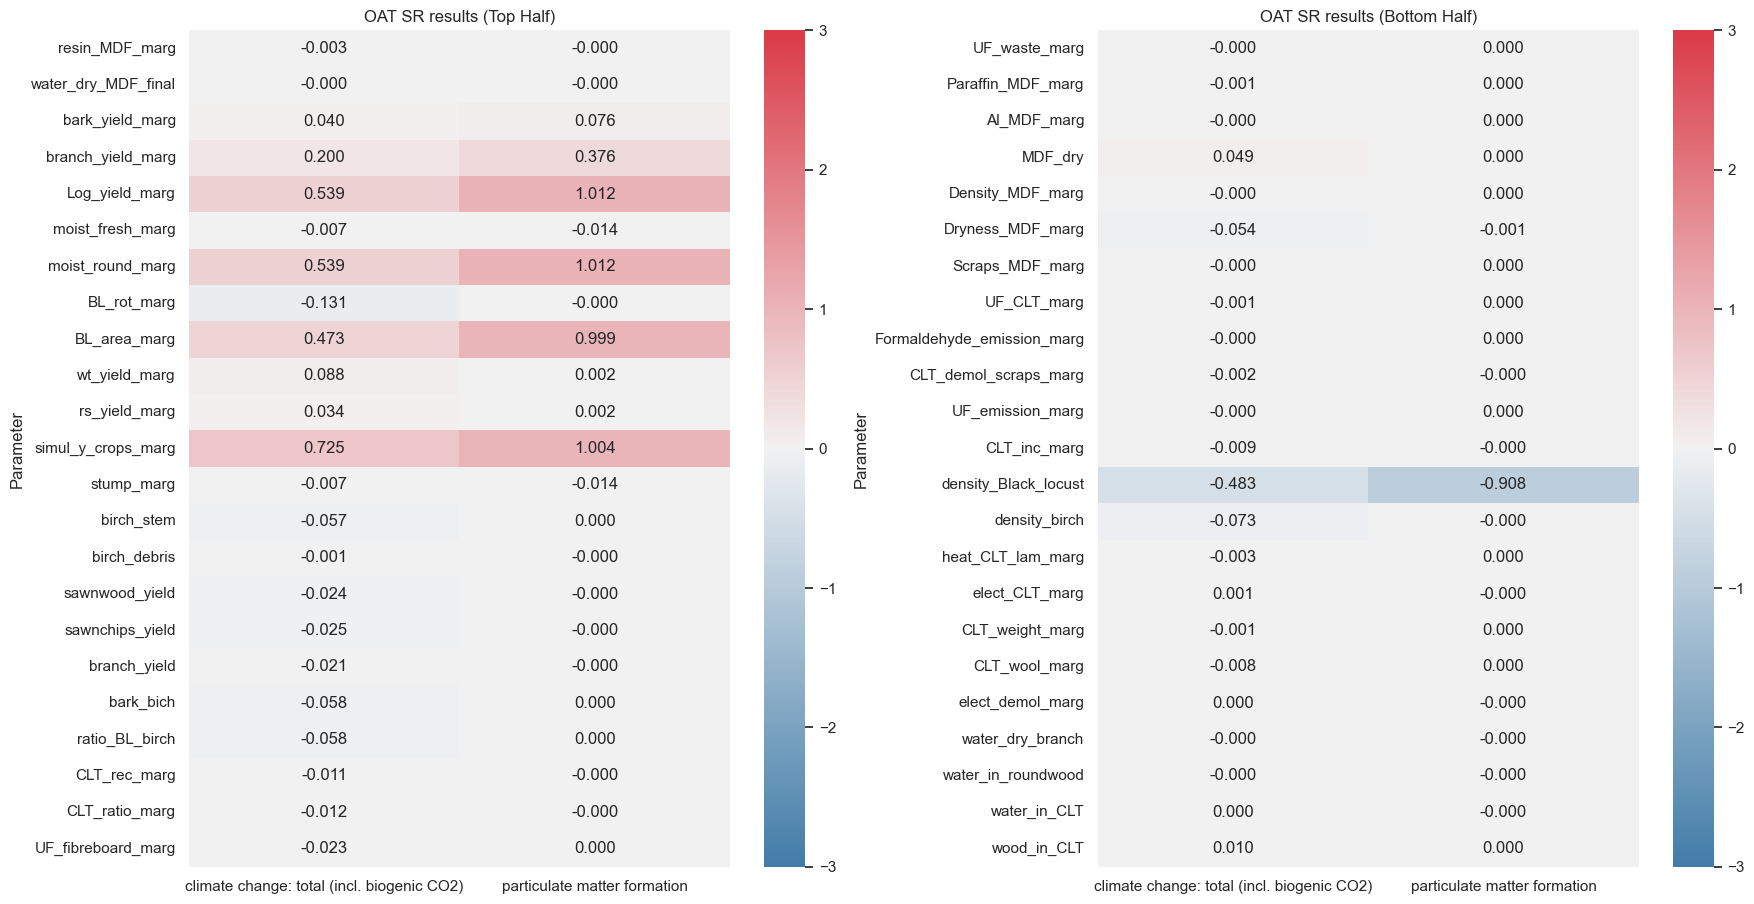

In [41]:
#Let's plot SRs as a heatmap. You can tweak this figure to your preferred desing

import matplotlib.pyplot as plt
import math

# Step 1: Combine SR results into a DataFrame
sr_df = pd.DataFrame()

for impact_category in results:
    par_name, par_values, lca_scores, SR_values = results[impact_category]
    temp_df = pd.DataFrame({impact_category: SR_values}, index=par_name)
    sr_df = pd.concat([sr_df, temp_df], axis=1)

# Step 2: Remove dummy parameters
sr_df = sr_df[~sr_df.index.str.startswith("__dummy_")]

# Optional: Sort by impact (e.g., climate change)
# sr_df = sr_df.sort_values(by='climate change', ascending=False)

# Step 3: Split into two parts (keeping labels accurate)
half = math.ceil(len(sr_df) / 2)
df_top = sr_df.iloc[:half].copy()
df_bottom = sr_df.iloc[half:].copy()

# Reset index to ensure seaborn shows correct labels
df_top.index.name = "Parameter"
df_bottom.index.name = "Parameter"

# Create the plot
sns.set(style="white")
cmap = sns.diverging_palette(240, 10, as_cmap=True)

fig, axs = plt.subplots(1, 2, figsize=(18, max(8, half * 0.4)), sharey=False)

sns.heatmap(df_top, annot=True, fmt='.3f', cmap=cmap, cbar=True, vmin=-3, vmax=3, ax=axs[0],
            yticklabels=True)

sns.heatmap(df_bottom, annot=True, fmt='.3f', cmap=cmap, cbar=True, vmin=-3, vmax=3, ax=axs[1],
            yticklabels=True)

axs[0].set_title("OAT SR results (Top Half)")
axs[1].set_title("OAT SR results (Bottom Half)")

plt.tight_layout()
plt.savefig("OAT_SR_split_heatmap_conv.png", dpi=300, bbox_inches="tight")  #make sure of using the right saving name
plt.show()

### **MonteCarlo** ##

For the MonteCarlo we are running LCA in multiple iterations changing the parameter values based on the probability distribution. So, first we need to sample the uncertainty of each parameter.

The following code allows us to run the Montecarlo sampling uncertainties only for the parameters identified as sensitive.

In [45]:
rng = np.random.default_rng(seed=42)  # seed optional but recommended

In [46]:
def sample_uncertainty(parameter, rng):
    d = parameter.dict
    if 'uncertainty type' not in d:
        raise ValueError("Parameter lacks uncertainty type")

    ut = d['uncertainty type']
    #rng = np.random.default_rng()

    loc = d.get('loc')
    scale = d.get('scale')
    shape = d.get('shape')
    minimum = d.get('minimum')
    maximum = d.get('maximum')

    if ut in (0, 1):  # Static value
        return loc

    elif ut == 2:  # Lognormal
        while True:
            sample = rng.lognormal(mean=loc, sigma=scale)
            if (minimum is None or sample >= minimum) and (maximum is None or sample <= maximum):
                return sample

    elif ut == 3:  # Normal
        while True:
            sample = rng.normal(loc, scale)
            if (minimum is None or sample >= minimum) and (maximum is None or sample <= maximum):
                return sample

    elif ut == 4:  # Uniform
        minimum = minimum if minimum is not None else 0
        return rng.uniform(minimum, maximum)

    elif ut == 5:  # Triangular
        return rng.triangular(minimum, loc, maximum)

    elif ut == 7:  # Discrete Uniform
        return rng.integers(minimum, maximum + 1)

    elif ut == 8:  # Weibull
        return scale * rng.weibull(shape)

    elif ut == 10:  # Beta
        sample = rng.beta(loc, shape)
        return scale * sample

    else:
        raise ValueError(f"Unknown uncertainty_type_id: {ut}")

In [51]:
#rng = np.random.default_rng()
mc_results = []
iterations = 10 # Adjust as needed

for j in range(iterations):
    print(f"\n🔁 Running iteration {j+1}/{iterations}")
    original = []

    # Update parameters with uncertainty
    for p in ActivityParameter:
        d = p.dict
        if d.get("uncertainty type") is None:
            continue  # Skip parameters without uncertainty definition

        try:
            original.append((p, p.amount))
            sampled_value = sample_uncertainty(p, rng)
            update_parameter(p, sampled_value)
        except Exception as e:
            print(f"⚠️  Error processing parameter {p.name}: {e}")

    # Run LCA after all parameters are updated
    results = []
    for m in methods:
        mc = bc.LCA(demand={FU: 1}, method=m, use_distributions=True)
        mc.lci()
        mc.lcia()
        results.append(mc.score)

    mc_results.append(results)

    # Restore original values
    for p, val in original:
        try:
            update_parameter(p, val)
        except Exception as e:
            print(f"⚠️  Error restoring parameter {p.name}: {e}")

print("\n✅ Monte Carlo simulation complete!")


🔁 Running iteration 1/10

🔁 Running iteration 2/10

🔁 Running iteration 3/10

🔁 Running iteration 4/10

🔁 Running iteration 5/10

🔁 Running iteration 6/10

🔁 Running iteration 7/10

🔁 Running iteration 8/10

🔁 Running iteration 9/10

🔁 Running iteration 10/10

✅ Monte Carlo simulation complete!


In [50]:
# Convert data to a DataFrame
method_names = [m[2]+' ('+ bd.methods[m]['unit']+')' for m in methods]
df = pd.DataFrame(mc_results, columns=  method_names)

df.index = np.arange(1, len(df) + 1)

df.to_excel("mc_results.xlsx", index=True)  #attention on the name of the saved file!
df.head(10)

,climate change: total (incl. biogenic CO2) (kg CO2-Eq),particulate matter formation (disease incidence)
1,-8.792098e+06,35.870387
2,-3.313035e+06,7.993422
3,-6.664935e+06,26.545203
4,-1.006526e+07,51.399762
5,-1.035044e+07,51.375282
6,-1.206071e+07,59.217530
7,-4.979605e+06,19.171483
8,-1.081456e+07,46.038226
9,-1.050154e+07,45.492257
10,-4.748175e+06,17.557777


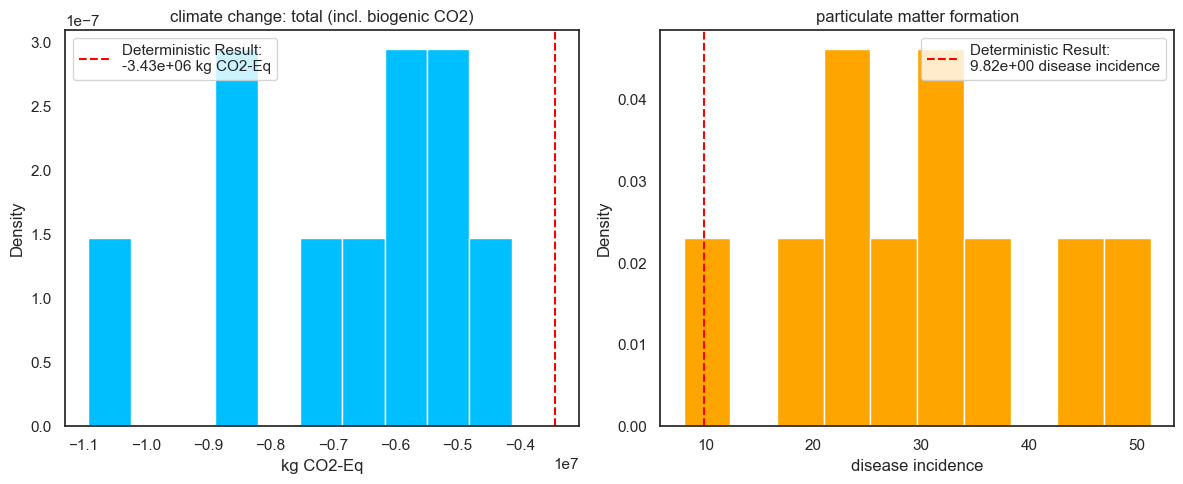

In [52]:
arr = np.array(mc_results)
impact1 = arr[:, 0]
impact2 = arr[:, 1]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Histogram for Impact 1
axs[0].hist(impact1, bins=10, density=True, color='deepskyblue')
axs[0].axvline(static_scores[0], color='red', linestyle='--', zorder = 1,
               label=f'Deterministic Result:\n{static_scores[0]:.2e} {bd.methods[methods[0]]["unit"]}')
axs[0].set_title(methods[0][2])
axs[0].set_xlabel(bd.methods[methods[0]]['unit'])
axs[0].set_ylabel('Density')
axs[0].legend()

# Histogram for Impact 2
axs[1].hist(impact2, bins=10, density=True, color='orange')
axs[1].axvline(static_scores[1], color='red', linestyle='--', zorder = 1,
               label=f'Deterministic Result:\n{static_scores[1]:.2e} {bd.methods[methods[1]]["unit"]}')
axs[1].set_title(methods[1][2])
axs[1].set_xlabel(bd.methods[methods[1]]['unit'])
axs[1].set_ylabel('Density')
axs[1].legend()

plt.tight_layout()
plt.show()

## **GSA** ##

GSA performs Sobol Index and Sobol Total calculations. <br>
Use workflow in para_gsa_bw25 available in GitHub : https://github.com/Christhel-Andrade?tab=repositories#:~:text=New-,para_gsa_bw25,-Public
